In [14]:
import json
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import redis
from langchain_openai import ChatOpenAI

# from redisvl.extensions.llmcache import SemanticCache
from redisvl.extensions.cache.llm import SemanticCache
from sentence_transformers import SentenceTransformer

from semantic_ai_agent.cache.config import config, load_openai_key
from semantic_ai_agent.cache.evals import CacheEvaluator, PerfEval
from semantic_ai_agent.cache.wrapper import SemanticCacheWrapper, try_connect_to_redis

warnings.filterwarnings("ignore")

In [15]:
REDIS_URL = config.get("redis_url", "redis://localhost:6379")

try:
    client = redis.from_url(REDIS_URL)
    client.ping()
    print("Redis connection successful")
    print(f"Connected to: {REDIS_URL}")
except Exception as e:
    print("Redis connection failed!")
    print(f"Error: {e}")
    print(
        "Please start Redis with: docker run -d --name redis -p 6379:6379 redis/redis-stack:latest"
    )

Redis connection successful
Connected to: redis://localhost:6379


In [16]:
faq_path = Path("../data/raw/faq_data.json")
with open(faq_path) as f:
    faq_raw = json.load(f)

df = pd.DataFrame(faq_raw)
print(f"Loaded {len(df)} FAQ pairs across {df['category'].nunique()} categories")
df.head()

Loaded 26 FAQ pairs across 8 categories


,question,response,category
0,How many vacation days do I get per year?,Full-time employees receive 15 paid vacation d...,vacation_pto
1,Can I carry over unused PTO to the next year?,You may carry over up to 5 unused vacation day...,vacation_pto
2,How do I request time off?,Submit your time-off request through the HR po...,vacation_pto
3,Is there a blackout period for vacation requests?,Vacation requests may be restricted during fis...,vacation_pto
4,What health insurance plans are available?,"We offer three plans: a Standard PPO, a High-D...",benefits


In [17]:
DISTANCE_THRESHOLD = 0.12  # ≈ 0.88 cosine similarity
TTL_SECONDS = 3600  # 2_592_000  # 30 days

cache = SemanticCacheWrapper(
    name="hr-faq-cache",
    distance_threshold=DISTANCE_THRESHOLD,
    ttl=TTL_SECONDS,
    redis_url=REDIS_URL,
)
print(f"Cache initialized: threshold={DISTANCE_THRESHOLD}, TTL={TTL_SECONDS}s")

Redis is running and accessible!
18:53:20 sentence_transformers.base.model INFO   No device provided, using cuda:0
18:53:20 sentence_transformers.base.model INFO   Loading SentenceTransformer model from redis/langcache-embed-v1.
18:53:24 redisvl.index.index INFO   Index already exists, not overwriting.
Cache initialized: threshold=0.12, TTL=3600s


In [18]:
import torch

print(torch.__version__)  # should show 2.10.0+cu128
print(torch.cuda.is_available())  # should show True

2.10.0+cu128
True


In [19]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA available: True
GPU: NVIDIA RTX A4000 Laptop GPU


In [20]:
import torch

print(f"CUDA available: {torch.cuda.is_available()}")
print(f"Device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

CUDA available: True
Device count: 1
GPU: NVIDIA RTX A4000 Laptop GPU


In [21]:
MODEL_NAME = "all-MiniLM-L6-v2"
embed_model = SentenceTransformer(MODEL_NAME)


def encode_query(text: str):
    """Encode a text query into a 384-dim embedding vector."""
    return embed_model.encode(text)


sample = encode_query("How many vacation days do I get?")
print(f"Model: {MODEL_NAME}")
print(f"Embedding dimension: {len(sample)}")
print(f"First 5 values: {sample[:5]}")

18:53:24 sentence_transformers.base.model INFO   No device provided, using cuda:0
18:53:24 sentence_transformers.base.model INFO   Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Model: all-MiniLM-L6-v2
Embedding dimension: 384
First 5 values: [ 0.04914931  0.01118137  0.02954269  0.06925448 -0.03390817]


In [22]:
cache.hydrate_from_df(df, q_col="question", a_col="response")
print(f"Cache hydrated with {len(df)} FAQ pairs")
print(f"Categories: {sorted(df['category'].unique())}")

Cache hydrated with 26 FAQ pairs
Categories: ['benefits', 'expenses_travel', 'general', 'onboarding', 'remote_work', 'salary_payroll', 'sick_family_leave', 'vacation_pto']


In [23]:
load_openai_key()

llm = ChatOpenAI(model="gpt-5.1", temperature=0)

HR_SYSTEM_PROMPT = (
    "You are an HR policy assistant. Answer the employee's question about company policies "
    "concisely and accurately in 2-3 sentences."
)


def mock_llm(query: str) -> str:
    """Simulate an LLM call with ~500ms latency (for offline testing)."""
    time.sleep(0.5)
    return f"[LLM response for: {query}]"


def ask_llm(query: str) -> str:
    """Call OpenAI to generate an HR policy answer."""
    response = llm.invoke(
        [
            {"role": "system", "content": HR_SYSTEM_PROMPT},
            {"role": "user", "content": query},
        ]
    )
    return str(response.content)


def get_cached_or_generate(query: str, llm_fn=ask_llm) -> str:
    """Check cache first; on miss, generate via LLM and store the result."""
    results = cache.check(query)

    if results.matches:
        match = results.matches[0]
        print(f"  HIT  | dist={match.vector_distance:.4f} | matched: {match.prompt[:60]}")
        return match.response

    print("  MISS | calling LLM...")
    response = llm_fn(query)
    cache.store(prompt=query, response=response)
    return response


test_response = get_cached_or_generate("What's the PTO allowance?")
print(f"\nResponse: {test_response[:100]}")

> OpenAI API key is already loaded in the environment
  MISS | calling LLM...
18:53:30 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"

Response: Our standard PTO allowance is 15 days per year for full-time employees, accrued monthly, plus compan


In [24]:
should_hit = [
    ("How many vacation days do I get?", "What's the PTO allowance?"),
    ("When is payday?", "What day do I get paid?"),
    ("What health insurance plans are available?", "Tell me about medical coverage options"),
    ("Can I work from home?", "What's the remote work policy?"),
    ("How do I submit an expense report?", "Where do I file my reimbursement?"),
    ("What is the maternity leave policy?", "How long is paid maternity leave?"),
]

should_miss = [
    ("How many vacation days do I get?", "How many sick days do I get?"),
    ("When is payday?", "When are annual raises decided?"),
    ("What's the remote work policy?", "What's the maternity leave policy?"),
    ("How do I submit an expense report?", "What is the meal allowance for travel?"),
    ("What health insurance plans are available?", "When is open enrollment?"),
]

print("=== SHOULD HIT (similar meaning) ===\n")
for cached_q, test_q in should_hit:
    result = cache.check(test_q)
    status = "HIT" if result.matches else "MISS"
    dist = result.matches[0].vector_distance if result.matches else None
    print(f'  [{status}] "{test_q}"')
    if result.matches:
        print(f'         matched: "{result.matches[0].prompt}" (dist={dist:.4f})')
    print()

print("=== SHOULD MISS (different intent) ===\n")
for cached_q, test_q in should_miss:
    result = cache.check(test_q)
    status = "HIT" if result.matches else "MISS"
    dist = result.matches[0].vector_distance if result.matches else None
    print(f'  [{status}] "{test_q}"')
    if result.matches:
        print(f'         matched: "{result.matches[0].prompt}" (dist={dist:.4f})')
    print()

=== SHOULD HIT (similar meaning) ===

  [HIT] "What's the PTO allowance?"
         matched: "What's the PTO allowance?" (dist=0.0000)

  [MISS] "What day do I get paid?"

  [MISS] "Tell me about medical coverage options"

  [HIT] "What's the remote work policy?"
         matched: "What is the remote work policy?" (dist=0.0346)

  [MISS] "Where do I file my reimbursement?"

  [MISS] "How long is paid maternity leave?"

=== SHOULD MISS (different intent) ===

  [HIT] "How many sick days do I get?"
         matched: "How many sick days do I get?" (dist=0.0000)

  [HIT] "When are annual raises decided?"
         matched: "When are annual raises decided?" (dist=0.0000)

  [HIT] "What's the maternity leave policy?"
         matched: "What is the maternity leave policy?" (dist=0.0203)

  [HIT] "What is the meal allowance for travel?"
         matched: "What is the meal allowance for business travel?" (dist=0.0463)

  [HIT] "When is open enrollment?"
         matched: "When is open enrollment?

  0%|          | 0/11 [00:00<?, ?it/s]

                                 query                                           match      distance  true_label
             What's the PTO allowance?                       What's the PTO allowance?  5.960464e-08        True
               What day do I get paid?                                 When is payday?  1.803101e-01        True
Tell me about medical coverage options      What health insurance plans are available?  1.529683e-01        True
        What's the remote work policy?                 What is the remote work policy?  3.461879e-02        True
     Where do I file my reimbursement?              How do I submit an expense report?  3.346977e-01        True
     How long is paid maternity leave?             What is the maternity leave policy?  2.207533e-01        True
          How many sick days do I get?                    How many sick days do I get?  1.192093e-07       False
       When are annual raises decided?                 When are annual raises decided?  5.960464

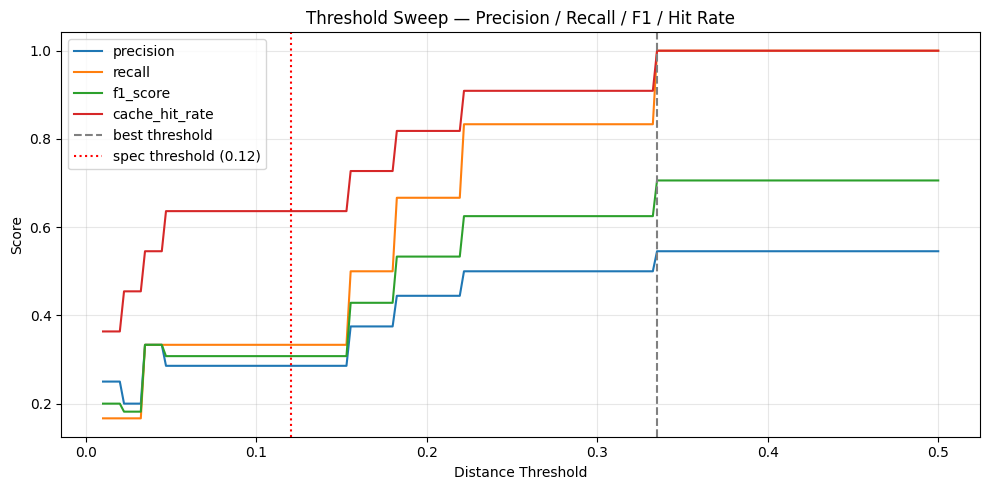

In [25]:
eval_queries = [q for _, q in should_hit] + [q for _, q in should_miss]
true_labels = [True] * len(should_hit) + [False] * len(should_miss)

cache_results = cache.check_many(eval_queries, distance_threshold=1.0, show_progress=True)

evaluator = CacheEvaluator.from_full_retrieval(true_labels, cache_results)

print(evaluator.matches_df().to_string(index=False))

sweep = evaluator.sweep_thresholds(
    metric_to_maximize="f1_score",
    threshold_range=(0.01, 0.5),
    num_samples=200,
)
print(f"\nBest threshold (F1): {sweep['best_threshold']:.4f}")

metrics_at_best = evaluator.get_metrics(sweep["best_threshold"])
print(f"  Precision:  {metrics_at_best['precision']:.2%}")
print(f"  Recall:     {metrics_at_best['recall']:.2%}")
print(f"  F1 Score:   {metrics_at_best['f1_score']:.2%}")
print(f"  Hit Rate:   {metrics_at_best['cache_hit_rate']:.2%}")

fig, ax = plt.subplots(figsize=(10, 5))
thresholds = sweep["thresholds"]
for metric_name in ["precision", "recall", "f1_score", "cache_hit_rate"]:
    ax.plot(thresholds, sweep["all_metrics"][metric_name], label=metric_name)
ax.axvline(sweep["best_threshold"], color="gray", linestyle="--", label="best threshold")
ax.axvline(
    DISTANCE_THRESHOLD, color="red", linestyle=":", label=f"spec threshold ({DISTANCE_THRESHOLD})"
)
ax.set_xlabel("Distance Threshold")
ax.set_ylabel("Score")
ax.set_title("Threshold Sweep — Precision / Recall / F1 / Hit Rate")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
test_queries = [
    # Vacation / PTO — rephrased
    "What's the PTO allowance?",
    "How much time off do new employees get?",
    "Can I roll over my unused vacation?",
    "What's the process for booking days off?",
    "Are there any dates when I can't take vacation?",
    # Benefits — rephrased
    "Tell me about medical coverage options",
    "Do we get dental?",
    "When can I switch my health plan?",
    "Can my kids be on my insurance?",
    # Salary / Payroll — rephrased
    "What day do I get paid?",
    "Where can I see my paycheck details?",
    "How do I change my direct deposit?",
    "When are annual raises decided?",
    "How do I update my bank account for payroll?",
    # Remote Work — rephrased
    "What's the remote work policy?",
    "Can I work fully remote?",
    "Is there a home office stipend?",
    "How many days can I work from home each week?",
    # Sick / Family Leave — rephrased
    "How many sick days do I get?",
    "How long is paid maternity leave?",
    "What's the maternity leave policy?",
    "Does the company offer paternity leave?",
    "What's the policy for calling in sick?",
    # Expenses / Travel — rephrased
    "Where do I file my reimbursement?",
    "What is the meal allowance for travel?",
    "How do I get reimbursed for a business trip?",
    "What expenses does the company cover for travel?",
    # Onboarding — rephrased
    "What should I expect on my first day?",
    "How do I set up my company email?",
    "Where can I find the employee handbook?",
    "What do I need to bring on day one?",
    # General — rephrased
    "What are the company holidays?",
    "How do I contact HR?",
    "Who do I talk to about an HR issue?",
    "Which days does the office close for holidays?",
]

perf = PerfEval()
perf.set_total_queries(len(test_queries))

with perf:
    hits = 0
    for query in test_queries:
        perf.start()
        result = cache.check(query)

        if result.matches:
            perf.tick("cache_hit")
            hits += 1
        else:
            perf.tick("cache_miss")
            perf.start()
            response = ask_llm(query)
            perf.tick("llm_call")
            perf.record_llm_call("gpt-5.1", query, response)
            cache.store(prompt=query, response=response)

hit_rate = hits / len(test_queries)
print(perf.summary(labels=["cache_hit", "llm_call"]))
print(f"\n{'=' * 40}")
print(f"Hit Rate: {hit_rate:.2%}  (target: 65%+)")
print(f"Cache hits: {hits}/{len(test_queries)}")
costs = perf.get_costs()
if costs["calls"] > 0:
    savings = hit_rate * 100
    print(f"Estimated cost reduction: {savings:.0f}%  (target: 70%+)")

18:53:33 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
18:53:35 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
18:53:37 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
18:53:39 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
18:53:41 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
18:53:42 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
18:53:44 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
18:53:46 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
18:53:48 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"
18:53:50 httpx INFO   HTTP Request: POST https://api.openai.com/v1/chat/completion

In [27]:
metrics = perf.get_metrics(labels=["cache_hit", "cache_miss", "llm_call"])
costs = perf.get_costs()
total_queries = len(test_queries)
misses = total_queries - hits

cache_hit_stats = metrics["by_label"].get("cache_hit", {})
llm_stats = metrics["by_label"].get("llm_call", {})

no_cache_cost = costs.get("avg_cost_per_call", 0.0) * total_queries if costs["calls"] > 0 else 0.0
actual_cost = costs["total_cost"]
cost_saved = no_cache_cost - actual_cost
cost_reduction_pct = (cost_saved / no_cache_cost * 100) if no_cache_cost > 0 else 0.0

avg_cache_ms = cache_hit_stats.get("average_latency_ms", 0.0)
avg_llm_ms = llm_stats.get("average_latency_ms", 0.0)
latency_reduction_pct = ((avg_llm_ms - avg_cache_ms) / avg_llm_ms * 100) if avg_llm_ms > 0 else 0.0

perf_data = {
    "Metric": [
        "Total queries",
        "Cache hits",
        "Cache misses",
        "Hit rate",
        "Hit rate target",
    ],
    "Value": [
        f"{total_queries}",
        f"{hits}",
        f"{misses}",
        f"{hit_rate:.1%}",
        "65%+",
    ],
}

latency_data = {
    "Metric": [
        "Avg cache-hit latency",
        "P50 cache-hit latency",
        "P95 cache-hit latency",
        "Avg LLM-call latency",
        "P50 LLM-call latency",
        "P95 LLM-call latency",
        "Latency reduction (cache vs LLM)",
        "Latency target (cache lookup)",
    ],
    "Value": [
        f"{avg_cache_ms:.1f} ms",
        f"{cache_hit_stats.get('p50_ms', 0.0):.1f} ms",
        f"{cache_hit_stats.get('p95_ms', 0.0):.1f} ms",
        f"{avg_llm_ms:.1f} ms",
        f"{llm_stats.get('p50_ms', 0.0):.1f} ms",
        f"{llm_stats.get('p95_ms', 0.0):.1f} ms",
        f"{latency_reduction_pct:.1f}%",
        "< 5 ms",
    ],
}

cost_data = {
    "Metric": [
        "LLM calls made",
        "LLM calls avoided (cache hits)",
        "API call reduction",
        "API call reduction target",
        "Total LLM cost (actual)",
        "Estimated cost without cache",
        "Cost saved",
        "Cost reduction",
        "Cost reduction target",
        "Avg cost per query (with cache)",
        "Avg cost per LLM call",
    ],
    "Value": [
        f"{costs['calls']}",
        f"{hits}",
        f"{hit_rate:.1%}",
        "70%+",
        f"${actual_cost:.4f}",
        f"${no_cache_cost:.4f}",
        f"${cost_saved:.4f}",
        f"{cost_reduction_pct:.1f}%",
        "70%+",
        f"${costs.get('avg_cost_per_query', 0.0):.6f}",
        f"${costs.get('avg_cost_per_call', 0.0):.6f}",
    ],
}

df_perf = pd.DataFrame(perf_data)
df_latency = pd.DataFrame(latency_data)
df_cost = pd.DataFrame(cost_data)

print("=" * 60)
print("       SEMANTIC CACHE — PERFORMANCE SUMMARY")
print("=" * 60)
print("\n--- Cache Effectiveness ---")
print(df_perf.to_string(index=False))
print("\n--- Latency ---")
print(df_latency.to_string(index=False))
print("\n--- Cost Analysis ---")
print(df_cost.to_string(index=False))
print("\n" + "=" * 60)

       SEMANTIC CACHE — PERFORMANCE SUMMARY

--- Cache Effectiveness ---
         Metric Value
  Total queries    35
     Cache hits    14
   Cache misses    21
       Hit rate 40.0%
Hit rate target  65%+

--- Latency ---
                          Metric     Value
           Avg cache-hit latency    3.4 ms
           P50 cache-hit latency    3.1 ms
           P95 cache-hit latency    5.2 ms
            Avg LLM-call latency 1868.8 ms
            P50 LLM-call latency 1886.1 ms
            P95 LLM-call latency 2445.8 ms
Latency reduction (cache vs LLM)     99.8%
   Latency target (cache lookup)    < 5 ms

--- Cost Analysis ---
                         Metric     Value
                 LLM calls made        21
 LLM calls avoided (cache hits)        14
             API call reduction     40.0%
      API call reduction target      70%+
        Total LLM cost (actual)   $0.0034
   Estimated cost without cache   $0.0057
                     Cost saved   $0.0023
                 Cost reduction 